# Module 3 — Garment Warping
### Virtual Fashion Fitting Room — style-cast

**What this module does:**
- Takes a flat garment image and warps it to fit the body shape
- Uses Thin Plate Spline (TPS) transformation driven by pose keypoints
- Produces a warped garment image and warped garment mask
- These become direct inputs to the cGAN in Module 4

**Inputs:**
- Flat garment image (e.g. product photo on white background)
- Garment mask (binary — white = garment, black = background)
- Agnostic image + agnostic mask (from Module 2)
- Pose keypoints JSON (from Module 1)

**Outputs:**
- `*_warped_garment.jpg` — garment warped to body shape
- `*_warped_mask.png` — warped garment mask
- `*_warped_grid.jpg` — TPS deformation grid (for debugging)

---

## How TPS warping works

Thin Plate Spline is a non-rigid transformation that bends a flat image  
onto a curved surface. Think of it like placing a sticker on a curved object —  
the sticker stretches and bends to conform to the surface shape.

```
Flat garment          Control points          Warped garment
┌─────────┐           (from keypoints)        ┌─────────┐
│  ▓▓▓▓▓ │  ──TPS──►  shoulder pts      ──►  │  ╱▓▓▓╲  │
│  ▓▓▓▓▓ │           + chest pts              │ ▓▓▓▓▓▓▓ │
│  ▓▓▓▓▓ │           + waist pts              │  ╲▓▓▓╱  │
└─────────┘                                   └─────────┘
```
---

## Step 1 — Imports

In [1]:
import cv2
import json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
import kornia

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"Kornia : {kornia.__version__}")

Device : cpu
Kornia : 0.8.2


## Step 2 — Garment control point definitions

TPS needs two sets of control points:
- **Source points** — where points are on the flat garment
- **Target points** — where those points should move to on the body

We derive target points from the pose keypoints (shoulders, chest, waist, arms).  
Source points are fixed relative positions on the garment image.

In [2]:
# COCO-18 keypoint indices (from Module 1)
KP = {
    'nose':           0,
    'neck':           1,
    'r_shoulder':     2,
    'r_elbow':        3,
    'r_wrist':        4,
    'l_shoulder':     5,
    'l_elbow':        6,
    'l_wrist':        7,
    'r_hip':          8,
    'r_knee':         9,
    'r_ankle':        10,
    'l_hip':          11,
    'l_knee':         12,
    'l_ankle':        13,
}

# def get_garment_target_points(keypoints, img_h, img_w, conf_threshold=0.3):
#     """
#     Derive TPS target control points from pose keypoints.

#     These are the body locations the garment edges should map TO.
#     Points are normalised to [-1, 1] range as required by kornia TPS.

#     Args:
#         keypoints    : list of 18 (x, y, conf) tuples from Module 1
#         img_h, img_w : image dimensions
#         conf_threshold: min confidence to use a keypoint

#     Returns:
#         target_pts : (N, 2) numpy array of normalised (x, y) coordinates
#         valid_mask : boolean array indicating which points are valid
#     """
#     def get_kp(idx):
#         x, y, c = keypoints[idx]
#         return np.array([x, y], dtype=np.float32), c >= conf_threshold

#     def midpoint(idx1, idx2):
#         p1, v1 = get_kp(idx1)
#         p2, v2 = get_kp(idx2)
#         return (p1 + p2) / 2, v1 and v2

#     def normalise(pt):
#         """ Convert pixel coords to [-1, 1] range """
#         return np.array([
#             pt[0] / img_w * 2 - 1,
#             pt[1] / img_h * 2 - 1
#         ], dtype=np.float32)

#     # Define 10 semantic control points on the body
#     # Each maps a garment edge/feature to a body location
#     r_shoulder, v0 = get_kp(KP['r_shoulder'])
#     l_shoulder, v1 = get_kp(KP['l_shoulder'])
#     r_elbow,    v2 = get_kp(KP['r_elbow'])
#     l_elbow,    v3 = get_kp(KP['l_elbow'])
#     r_hip,      v4 = get_kp(KP['r_hip'])
#     l_hip,      v5 = get_kp(KP['l_hip'])
#     neck,       v6 = get_kp(KP['neck'])
#     r_wrist,    v7 = get_kp(KP['r_wrist'])
#     l_wrist,    v8 = get_kp(KP['l_wrist'])
#     chest_mid,  v9 = midpoint(KP['r_shoulder'], KP['l_shoulder'])
#     waist_mid,  v10= midpoint(KP['r_hip'],      KP['l_hip'])

#     raw_points = [
#         (r_shoulder, v0),   # 0  right shoulder
#         (l_shoulder, v1),   # 1  left shoulder
#         (r_elbow,    v2),   # 2  right elbow
#         (l_elbow,    v3),   # 3  left elbow
#         (r_hip,      v4),   # 4  right hip
#         (l_hip,      v5),   # 5  left hip
#         (neck,       v6),   # 6  neck
#         (r_wrist,    v7),   # 7  right wrist
#         (l_wrist,    v8),   # 8  left wrist
#         (chest_mid,  v9),   # 9  chest centre
#         (waist_mid,  v10),  # 10 waist centre
#     ]

#     target_pts  = np.array([normalise(p) for p, _ in raw_points], dtype=np.float32)
#     valid_mask  = np.array([v for _, v in raw_points], dtype=bool)

#     return target_pts, valid_mask

def get_garment_target_points(keypoints, img_h, img_w, conf_threshold=0.3):

    lm = keypoints

    def get_kp(idx):
        x, y, c = lm[idx]
        return np.array([x, y], dtype=np.float32), c >= conf_threshold

    def midpoint(i, j):
        p1, v1 = get_kp(i)
        p2, v2 = get_kp(j)
        return (p1 + p2) / 2, v1 and v2

    def norm(pt):
        return np.array([pt[0]/img_w*2-1, pt[1]/img_h*2-1], dtype=np.float32)

    r_shoulder, v0 = get_kp(KP['r_shoulder'])
    l_shoulder, v1 = get_kp(KP['l_shoulder'])
    r_elbow,    v2 = get_kp(KP['r_elbow'])
    l_elbow,    v3 = get_kp(KP['l_elbow'])
    r_hip,      v4 = get_kp(KP['r_hip'])
    l_hip,      v5 = get_kp(KP['l_hip'])
    neck,       v6 = get_kp(KP['neck'])
    r_wrist,    v7 = get_kp(KP['r_wrist'])
    l_wrist,    v8 = get_kp(KP['l_wrist'])
    chest_mid,  v9 = midpoint(KP['r_shoulder'], KP['l_shoulder'])
    waist_mid,  v10= midpoint(KP['r_hip'],      KP['l_hip'])

    raw_points = [
        (r_shoulder, v0),
        (l_shoulder, v1),
        (r_elbow,    v2),
        (l_elbow,    v3),
        (r_hip,      v4),
        (l_hip,      v5),
        (neck,       v6),
        (r_wrist,    v7),
        (l_wrist,    v8),
        (chest_mid,  v9),
        (waist_mid,  v10),
        # ── Boundary anchors — always valid, always identity ──
        (np.array([0.,        0.]),        True),
        (np.array([img_w-1.,  0.]),        True),
        (np.array([0.,        img_h-1.]),  True),
        (np.array([img_w-1.,  img_h-1.]), True),
        (np.array([img_w/2,   0.]),        True),
        (np.array([img_w/2,   img_h-1.]), True),
        (np.array([0.,        img_h/2]),   True),
        (np.array([img_w-1.,  img_h/2]),  True),
    ]

    target_pts = np.array([norm(p) for p, _ in raw_points], dtype=np.float32)
    valid_mask = np.array([v for _, v in raw_points], dtype=bool)

    return target_pts, valid_mask


# def get_garment_source_points(garment_h, garment_w):
#     """
#     Define fixed source control points on the flat garment image.

#     These correspond semantically to the target points above:
#     right shoulder on garment → right shoulder on body, etc.

#     Points are normalised to [-1, 1] range.
#     """
#     # Relative positions on a typical flat-lay garment image
#     # (x, y) as fractions of image size
#     # relative_pts = [
#     #     (0.75, 0.10),  # 0  right shoulder
#     #     (0.25, 0.10),  # 1  left shoulder
#     #     (0.90, 0.40),  # 2  right elbow
#     #     (0.10, 0.40),  # 3  left elbow
#     #     (0.75, 0.90),  # 4  right hip
#     #     (0.25, 0.90),  # 5  left hip
#     #     (0.50, 0.05),  # 6  neck/collar centre
#     #     (0.95, 0.65),  # 7  right wrist
#     #     (0.05, 0.65),  # 8  left wrist
#     #     (0.50, 0.25),  # 9  chest centre
#     #     (0.50, 0.80),  # 10 waist centre
#     # ]
#     relative_pts = [
#     (0.25, 0.10),  # 0  right shoulder — person's right = LEFT of image
#     (0.75, 0.10),  # 1  left shoulder  — person's left  = RIGHT of image
#     (0.10, 0.40),  # 2  right elbow
#     (0.90, 0.40),  # 3  left elbow
#     (0.25, 0.90),  # 4  right hip
#     (0.75, 0.90),  # 5  left hip
#     (0.50, 0.05),  # 6  neck/collar centre
#     (0.05, 0.65),  # 7  right wrist
#     (0.95, 0.65),  # 8  left wrist
#     (0.50, 0.25),  # 9  chest centre
#     (0.50, 0.80),  # 10 waist centre
#     ]

#     source_pts = np.array([
#         [x * 2 - 1, y * 2 - 1]   # normalise to [-1, 1]
#         for x, y in relative_pts
#     ], dtype=np.float32)

#     return source_pts

def get_garment_source_points(target_h, target_w):
    relative_pts = [
        (0.25, 0.10),  # 0  right shoulder
        (0.75, 0.10),  # 1  left shoulder
        (0.10, 0.40),  # 2  right elbow
        (0.90, 0.40),  # 3  left elbow
        (0.25, 0.90),  # 4  right hip
        (0.75, 0.90),  # 5  left hip
        (0.50, 0.05),  # 6  neck
        (0.05, 0.65),  # 7  right wrist
        (0.95, 0.65),  # 8  left wrist
        (0.50, 0.25),  # 9  chest centre
        (0.50, 0.80),  # 10 waist centre
        # ── Boundary anchors ──────────────────
        (0.0,  0.0),   # 11 top-left corner
        (1.0,  0.0),   # 12 top-right corner
        (0.0,  1.0),   # 13 bottom-left corner
        (1.0,  1.0),   # 14 bottom-right corner
        (0.5,  0.0),   # 15 top-centre
        (0.5,  1.0),   # 16 bottom-centre
        (0.0,  0.5),   # 17 left-centre
        (1.0,  0.5),   # 18 right-centre
    ]
    source_pts = np.array(
        [[x * 2 - 1, y * 2 - 1] for x, y in relative_pts],
        dtype=np.float32
    )
    return source_pts

print("Control point functions defined.")

Control point functions defined.


## Step 3 — TPS Warper class

In [33]:
from scipy.interpolate import RBFInterpolator

class TPSGarmentWarper:

    def __init__(self, device='cpu'):
        self.device = device

    def warp(self, garment_rgb, garment_mask, keypoints,
             target_h, target_w, conf_threshold=0.3):

        garment_resized = cv2.resize(garment_rgb,  (target_w, target_h))
        mask_resized    = cv2.resize(garment_mask, (target_w, target_h),
                                      interpolation=cv2.INTER_NEAREST)

        upper_indices = [2, 5, 8, 11]
        upper_pts = [(keypoints[i][0], keypoints[i][1])
                      for i in upper_indices
                      if keypoints[i][2] >= conf_threshold]

        if len(upper_pts) < 2:
            upper_pts = [(x, y) for x, y, c in keypoints
                         if c >= conf_threshold and x > 0 and y > 0]

        if len(upper_pts) < 2:
            print("WARNING: Too few keypoints. Returning identity.")
            return self._identity_result(garment_resized, mask_resized)

        xs = [p[0] for p in upper_pts]
        ys = [p[1] for p in upper_pts]

        pad_x = int((max(xs) - min(xs)) * 0.5)   # wider horizontal padding
        pad_y = int((max(ys) - min(ys)) * 0.3)  # reduce from 0.8
        bx1 = max(0,        min(xs) - pad_x)
        bx2 = min(target_w, max(xs) + pad_x)
        by1 = max(0,        min(ys) - pad_y)
        by2 = min(target_h, max(ys) + pad_y)

        body_w = bx2 - bx1
        body_h = by2 - by1

        print(f"  Body bounding box : ({bx1},{by1}) → ({bx2},{by2})")
        print(f"  Body region size  : {body_w}x{body_h}")

        contours, _ = cv2.findContours(mask_resized, cv2.RETR_EXTERNAL,
                                        cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            print("WARNING: No garment contour found.")
            return self._identity_result(garment_resized, mask_resized)

        gx, gy, gw, gh = cv2.boundingRect(max(contours, key=cv2.contourArea))
        print(f"  Garment region    : ({gx},{gy}) size {gw}x{gh}")

        scale = min(body_w / gw, body_h / gh) * 1.25  # slightly bigger
        pad_y = int((max(ys) - min(ys)) * 0.5)
        new_w = int(gw * scale)
        new_h = int(gh * scale)

        garment_crop   = garment_resized[gy:gy+gh, gx:gx+gw]
        mask_crop      = mask_resized[gy:gy+gh, gx:gx+gw]
        garment_scaled = cv2.resize(garment_crop, (new_w, new_h))
        mask_scaled    = cv2.resize(mask_crop,    (new_w, new_h),
                                     interpolation=cv2.INTER_NEAREST)

        warped_garment = np.ones((target_h, target_w, 3), dtype=np.uint8) * 128
        warped_mask    = np.zeros((target_h, target_w),   dtype=np.uint8)

        paste_x = bx1 + (body_w - new_w) // 2
        paste_y = by1 + (body_h - new_h) // 2
        # After computing paste_y, shift it down by 20px
        paste_y = paste_y + 20
        paste_x = int(np.clip(paste_x, 0, target_w - new_w))
        paste_y = int(np.clip(paste_y, 0, target_h - new_h))
        # Add this line below:
        paste_y = int(np.clip(paste_y + 20, 0, target_h - new_h))

        warped_garment[paste_y:paste_y+new_h, paste_x:paste_x+new_w] = garment_scaled
        warped_mask[paste_y:paste_y+new_h,    paste_x:paste_x+new_w] = mask_scaled

        _, warped_mask = cv2.threshold(warped_mask, 127, 255, cv2.THRESH_BINARY)

        grid_vis = np.ones((target_h, target_w, 3), dtype=np.uint8) * 240
        cv2.rectangle(grid_vis, (bx1, by1), (bx2, by2), (100, 149, 237), 2)
        cv2.rectangle(grid_vis,
                      (paste_x, paste_y),
                      (paste_x+new_w, paste_y+new_h),
                      (200, 100, 50), 2)
        cv2.putText(grid_vis, "Body box",
                    (bx1+5, by1+20), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (100, 149, 237), 1)
        cv2.putText(grid_vis, "Garment placement",
                    (paste_x+5, paste_y+20), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (200, 100, 50), 1)

        coverage = np.sum(warped_mask == 255) / warped_mask.size * 100
        print(f"  Mask coverage     : {coverage:.1f}%")

        return {
            'warped_garment': warped_garment,
            'warped_mask':    warped_mask,
            'grid_vis':       grid_vis,
            'source_pts':     np.array([]),
            'target_pts':     np.array([]),
            'num_pts':        len(upper_pts)
        }

    def _identity_result(self, garment, mask):
        return {
            'warped_garment': garment,
            'warped_mask':    mask,
            'grid_vis':       np.ones((garment.shape[0], garment.shape[1], 3),
                                       dtype=np.uint8) * 240,
            'source_pts':     np.array([]),
            'target_pts':     np.array([]),
            'num_pts':        0
        }

print("TPSGarmentWarper defined.")

TPSGarmentWarper defined.


## Step 4 — Garment mask generator

If your garment image has a white/plain background (typical product photo),  
we can auto-generate the mask. Otherwise you can provide one manually.

In [5]:
def generate_garment_mask(garment_rgb, bg_threshold=240):
    """
    Auto-generate a garment mask from a white-background product image.

    Args:
        garment_rgb   : (H, W, 3) RGB garment image
        bg_threshold  : pixel brightness above which we consider background

    Returns:
        mask : (H, W) uint8 — 255 = garment, 0 = background
    """
    gray = cv2.cvtColor(garment_rgb, cv2.COLOR_RGB2GRAY)

    # Threshold — dark pixels = garment, bright pixels = background
    _, mask = cv2.threshold(gray, bg_threshold, 255, cv2.THRESH_BINARY_INV)

    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)

    # Fill internal holes (e.g. light-coloured patterns on dark fabric)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        filled  = np.zeros_like(mask)
        cv2.drawContours(filled, [largest], -1, 255, thickness=cv2.FILLED)
        mask = filled

    return mask


def load_keypoints_from_json(json_path):
    """ Load Module 1 keypoints JSON """
    with open(json_path) as f:
        data = json.load(f)
    flat = data['people'][0]['pose_keypoints_2d']
    return [(int(flat[i]), int(flat[i+1]), float(flat[i+2])) for i in range(0, len(flat), 3)]


print("Garment mask and loader functions defined.")

Garment mask and loader functions defined.


## Step 5 — Visualisation

In [6]:
def show_warping_results(garment_rgb, garment_mask, result, person_rgb, agnostic_rgb):
    """
    5-panel visualisation:
    Flat garment | Garment mask | Deformation grid | Warped garment | Preview blend
    """
    # Quick blend preview — warped garment over agnostic image
    preview = agnostic_rgb.copy()
    warp_mask_3ch = np.stack([result['warped_mask']] * 3, axis=-1) / 255.0
    preview = (preview * (1 - warp_mask_3ch) +
               result['warped_garment'] * warp_mask_3ch).astype(np.uint8)

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(garment_rgb)
    axes[0].set_title('Flat garment')
    axes[0].axis('off')

    axes[1].imshow(garment_mask, cmap='gray')
    axes[1].set_title('Garment mask')
    axes[1].axis('off')

    axes[2].imshow(result['grid_vis'])
    axes[2].set_title(f"TPS deformation grid\n({result['num_pts']} control points)")
    axes[2].axis('off')

    axes[3].imshow(result['warped_garment'])
    axes[3].set_title('Warped garment')
    axes[3].axis('off')

    axes[4].imshow(preview)
    axes[4].set_title('Blend preview\n(before GAN refinement)')
    axes[4].axis('off')

    plt.suptitle('Module 3 — Garment Warping Results', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"Control points used : {result['num_pts']}")
    print(f"Warped garment shape: {result['warped_garment'].shape}")
    print(f"Warped mask coverage: {np.sum(result['warped_mask'] == 255) / result['warped_mask'].size * 100:.1f}%")


def show_control_points(garment_rgb, person_rgb, src_pts, tgt_pts, img_h, img_w):
    """
    Visualise source control points on garment and
    target control points on person image side by side.
    """
    def denorm(pts, h, w):
        """ Convert [-1,1] coords back to pixel coords """
        px = (pts[:, 0] + 1) / 2 * w
        py = (pts[:, 1] + 1) / 2 * h
        return np.stack([px, py], axis=1).astype(int)

    src_px = denorm(src_pts, garment_rgb.shape[0], garment_rgb.shape[1])
    tgt_px = denorm(tgt_pts, img_h, img_w)

    g_canvas = garment_rgb.copy()
    p_canvas = cv2.resize(person_rgb, (img_w, img_h))

    colors = plt.cm.Set1(np.linspace(0, 1, len(src_px)))

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(g_canvas)
    for i, (x, y) in enumerate(src_px):
        axes[0].plot(x, y, 'o', color=colors[i], markersize=10)
        axes[0].annotate(str(i), (x, y), fontsize=8, color='white',
                         ha='center', va='center', fontweight='bold')
    axes[0].set_title('Source control points (garment)')
    axes[0].axis('off')

    axes[1].imshow(p_canvas)
    for i, (x, y) in enumerate(tgt_px):
        axes[1].plot(x, y, 'o', color=colors[i], markersize=10)
        axes[1].annotate(str(i), (x, y), fontsize=8, color='white',
                         ha='center', va='center', fontweight='bold')
    axes[1].set_title('Target control points (body)')
    axes[1].axis('off')

    plt.suptitle('Matching control points — same colour = same point', fontsize=11)
    plt.tight_layout()
    plt.show()

print("Visualisation functions defined.")

Visualisation functions defined.


## Step 6 — Run on test image

In [34]:
# ─── CONFIG ───────────────────────────────────────────────────────────────────
PERSON_IMAGE_PATH   = "data/test-image.jpg"         # Module 1 input
GARMENT_IMAGE_PATH  = "data/garment.jpg"                     # flat-lay garment
GARMENT_MASK_PATH   = None                                        # set to path if you have one
                                                                   # or None to auto-generate
POSE_JSON_PATH      = "outputs/pose/test-image_keypoints.json"  # Module 1 output
AGNOSTIC_IMAGE_PATH = "outputs/segmentation/test-image_agnostic.jpg" # Module 2 output
OUTPUT_DIR          = Path("outputs/warping")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# ──────────────────────────────────────────────────────────────────────────────

# Load images
person_bgr   = cv2.imread(PERSON_IMAGE_PATH)
person_rgb   = cv2.cvtColor(person_bgr, cv2.COLOR_BGR2RGB)
garment_bgr  = cv2.imread(GARMENT_IMAGE_PATH)
garment_rgb  = cv2.cvtColor(garment_bgr, cv2.COLOR_BGR2RGB)
agnostic_bgr = cv2.imread(AGNOSTIC_IMAGE_PATH)
agnostic_rgb = cv2.cvtColor(agnostic_bgr, cv2.COLOR_BGR2RGB)

# Load or generate garment mask
if GARMENT_MASK_PATH and Path(GARMENT_MASK_PATH).exists():
    garment_mask = cv2.imread(GARMENT_MASK_PATH, cv2.IMREAD_GRAYSCALE)
    print("Garment mask loaded from file.")
else:
    garment_mask = generate_garment_mask(garment_rgb)
    print("Garment mask auto-generated from background.")

# Load keypoints
keypoints = load_keypoints_from_json(POSE_JSON_PATH)

target_h, target_w = person_rgb.shape[:2]

print(f"Person image  : {target_w}x{target_h}")
print(f"Garment image : {garment_rgb.shape[1]}x{garment_rgb.shape[0]}")
print(f"Keypoints     : {len(keypoints)}")

Garment mask auto-generated from background.
Person image  : 4912x7360
Garment image : 1946x1946
Keypoints     : 18


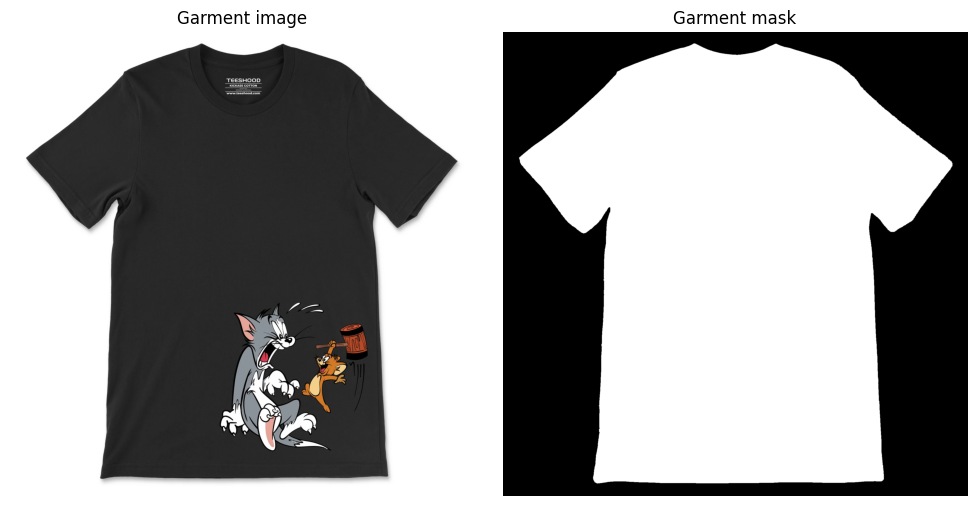

In [35]:
# Verify garment mask looks correct before warping
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(garment_rgb)
axes[0].set_title('Garment image')
axes[0].axis('off')
axes[1].imshow(garment_mask, cmap='gray')
axes[1].set_title('Garment mask')
axes[1].axis('off')
plt.tight_layout()
plt.show()

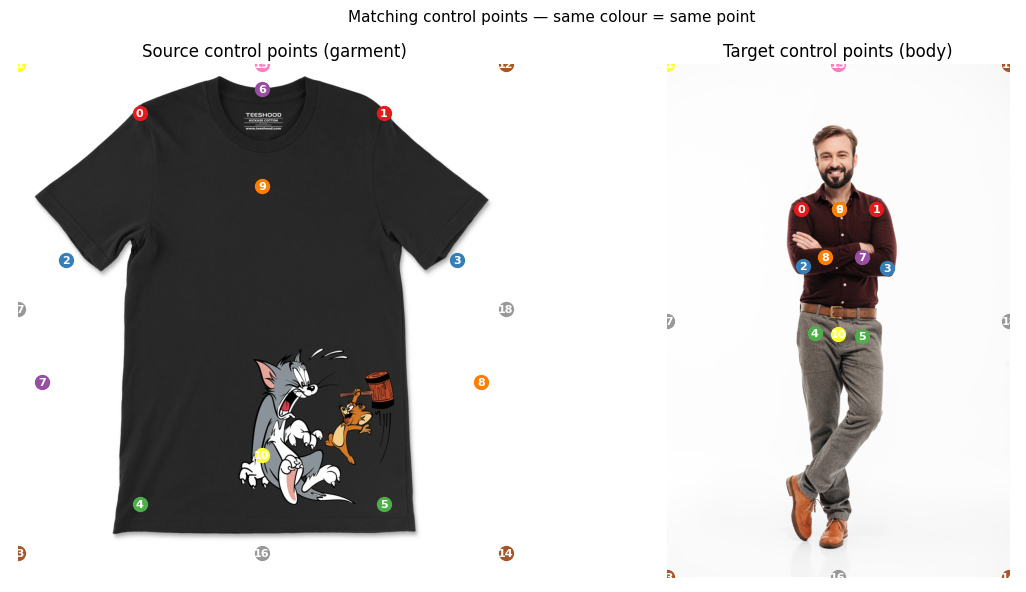

In [36]:
# Visualise control points before warping
src_pts = get_garment_source_points(target_h, target_w)
tgt_pts, valid = get_garment_target_points(keypoints, target_h, target_w)

show_control_points(
    garment_rgb, person_rgb,
    src_pts[valid], tgt_pts[valid],
    target_h, target_w
)

In [37]:
# Run TPS warping
warper = TPSGarmentWarper(device=DEVICE)

# ── Resize everything to 512x384 ─────────────────────────────────────────
TARGET_H, TARGET_W = 512, 384

person_rgb   = cv2.resize(person_rgb,   (TARGET_W, TARGET_H))
agnostic_rgb = cv2.resize(agnostic_rgb, (TARGET_W, TARGET_H))
garment_rgb  = cv2.resize(garment_rgb,  (TARGET_W, TARGET_H))
garment_mask = cv2.resize(garment_mask, (TARGET_W, TARGET_H),
                           interpolation=cv2.INTER_NEAREST)

target_h, target_w = TARGET_H, TARGET_W
print(f"All images resized to {TARGET_W}x{TARGET_H}")

# ── Rescale keypoints to match new resolution ─────────────────────────────
original_h, original_w = 7360, 4912
scale_x = TARGET_W / original_w
scale_y = TARGET_H / original_h

keypoints = [
    (int(x * scale_x), int(y * scale_y), c)
    for x, y, c in keypoints
]
print("Keypoints rescaled ✓")

# ── Warp ──────────────────────────────────────────────────────────────────
result = warper.warp(
    garment_rgb  = garment_rgb,
    garment_mask = garment_mask,
    keypoints    = keypoints,
    target_h     = target_h,
    target_w     = target_w
)
print(f"Warping complete — {result['num_pts']} control points used")

All images resized to 384x512
Keypoints rescaled ✓
  Body bounding box : (108,107) → (277,307)
  Body region size  : 169x200
  Garment region    : (14,14) size 358x485
  Mask coverage     : 15.8%
Warping complete — 4 control points used


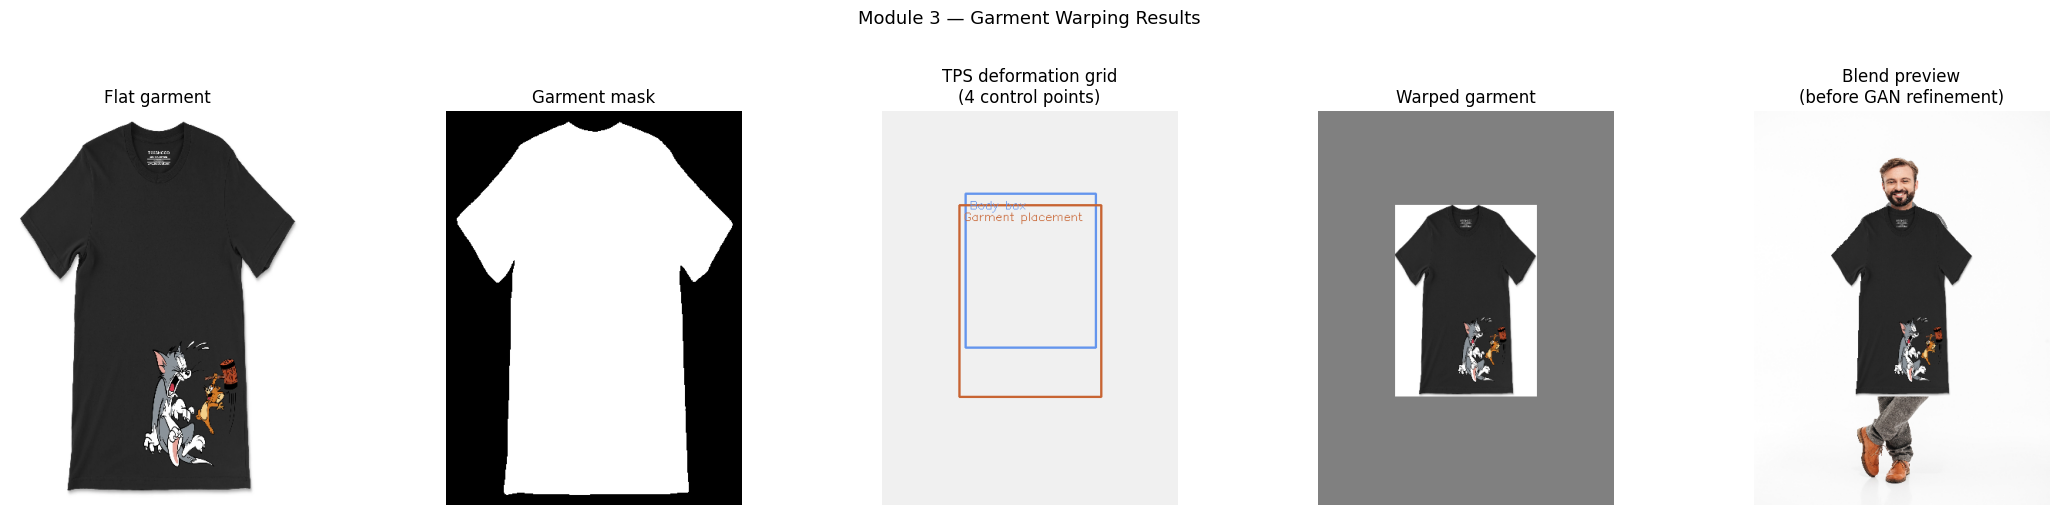

Control points used : 4
Warped garment shape: (512, 384, 3)
Warped mask coverage: 15.8%


In [38]:
# Visualise all results
show_warping_results(garment_rgb, garment_mask, result, person_rgb, agnostic_rgb)

## Step 7 — Tuning tips

**If the warping looks wrong:**

| Problem | Fix |
|---|---|
| Garment too small / large | Adjust `relative_pts` in `get_garment_source_points` |
| Garment shifted left/right | Shoulder source points need adjustment |
| Sleeve ends not aligning | Tune wrist points `(0.95, 0.65)` and `(0.05, 0.65)` |
| Too few control points warning | Lower `conf_threshold` from 0.3 to 0.2 |
| Garment mask missing parts | Lower `bg_threshold` in `generate_garment_mask` |

## Step 8 — Save outputs

In [39]:
stem = Path(PERSON_IMAGE_PATH).stem

# Warped garment image
warped_path = OUTPUT_DIR / f"{stem}_warped_garment.jpg"
cv2.imwrite(str(warped_path),
            cv2.cvtColor(result['warped_garment'], cv2.COLOR_RGB2BGR),
            [cv2.IMWRITE_JPEG_QUALITY, 95])
print(f"Warped garment  : {warped_path}")

# Warped mask
mask_path = OUTPUT_DIR / f"{stem}_warped_mask.png"
cv2.imwrite(str(mask_path), result['warped_mask'])
print(f"Warped mask     : {mask_path}")

# Deformation grid visualisation
grid_path = OUTPUT_DIR / f"{stem}_warp_grid.jpg"
cv2.imwrite(str(grid_path),
            cv2.cvtColor(result['grid_vis'], cv2.COLOR_RGB2BGR))
print(f"Warp grid       : {grid_path}")

print("\n✓ All warping outputs saved.")

Warped garment  : outputs/warping/test-image_warped_garment.jpg
Warped mask     : outputs/warping/test-image_warped_mask.png
Warp grid       : outputs/warping/test-image_warp_grid.jpg

✓ All warping outputs saved.


---
## Summary

| Output file | Content | Used by |
|---|---|---|
| `*_warped_garment.jpg` | Garment warped to body shape | HR-VITON generator input |
| `*_warped_mask.png` | Warped garment region mask | Composite blending |
| `*_warp_grid.jpg` | TPS deformation grid | Debugging / report figures |

**Next module:** HR-VITON inference — loads pretrained weights and runs the  
cGAN generator using the agnostic image + warped garment to produce the final try-on result.